In [1]:
import sys
sys.path.append('../src')

In [2]:
from gso.manifolds import AlgebraicManifold, plot_manifold
from gso.graph_sampling import GraphSampler
from gso.signal_generation import SignalGenerator
from gso.gso_learning import DiffusionMap, block_descent, laplacian_error_metrics, cgl_fit, glasso_fit

In [3]:
import time
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from scipy.linalg import pinvh
import json
from datetime import datetime

In [4]:
import networkx as nx
from scipy.sparse import csr_matrix

def create_sbm(sizes: list, probs: list, seed=None) -> csr_matrix:
    """
    Generate SBM graph as compressed sparse row matrix.
    
    Parameters:
    sizes : list of ints        # Nodes per community
    probs : 2D list of floats   # Inter/intra-community edge probabilities
    seed  : int (optional)      # Random seed
    
    Returns:
    csr_matrix                  # Sparse adjacency matrix
    """
    g = nx.stochastic_block_model(sizes, probs, seed=seed)
    return nx.adjacency_matrix(g).tocsr()

In [5]:
num_equations = 2
num_variables = 4
max_degree = 4
seed = 22

M = AlgebraicManifold(num_equations, num_variables, max_degree, seed)

sizes = [33, 33, 33]
num_nodes = sum(sizes)
probs = np.array([[0.3, 0.01, 0.02],
                  [0.01, 0.25, 0.03],
                  [0.02, 0.03, 0.2]])
structure = create_sbm(sizes, probs, seed)

L, W, point_cloud, epsilon = GraphSampler().create_weighted_graph_from_structure(M, structure)
L_dense = L.toarray()
np.fill_diagonal(L_dense, 0)
print(np.shape(L_dense))

(99, 99)


In [6]:
def generate_graph_signals(L, num_signals=1, noise_std=0.0):
    """
    Generate graph signals from a Gaussian distribution with precision matrix L (Laplacian).
    Signals are generated as samples from N(0, L^+), where L^+ is the pseudo-inverse of L,
    aligning with the assumptions of Laplacian learning techniques that model the Laplacian
    as the precision matrix in a Gaussian Markov Random Field.

    Args:
        L (np.ndarray): Laplacian matrix (n x n), assumed to be symmetric and positive semi-definite
        num_signals (int): Number of graph signals to generate (default: 1)
        noise_std (float): Standard deviation of additive Gaussian noise (default: 0.0)

    Returns:
        np.ndarray: Generated graph signals (n x num_signals), where each column is a signal
    """
    n = L.shape[0]
    eigvals, eigvecs = np.linalg.eigh(L)

    tol = 1e-6
    inv_eigvals = np.array([1.0 / ev if ev > tol else 0.0 for ev in eigvals])
    
    sqrt_inv_eigvals = np.sqrt(inv_eigvals)
    L_pinv_sqrt = eigvecs @ np.diag(sqrt_inv_eigvals) @ eigvecs.T
    
    signals = np.zeros((n, num_signals))
    for i in range(num_signals):
        z = np.random.randn(n)
        x = L_pinv_sqrt @ z
        if noise_std > 0:
            x += np.random.randn(n) * noise_std
        signals[:, i] = x

    return signals

In [7]:
S = generate_graph_signals(L_dense, num_signals=1000)

In [8]:
def plot_trajectories(data, num_trajectories, figsize=(5, 3)):
    selected_points = np.random.choice(S.shape[1], size=num_trajectories, replace=False)

    plt.figure(figsize=figsize)

    colors = ['b', 'g', 'r', 'c', 'm', 'y', 'k']
    markers = ['o', 's', 'D', '^', 'v', '<', '>']

    for i, col in enumerate(selected_points):
        plt.plot(
            data[:, col],
            color=colors[i % len(colors)],
            marker=markers[i % len(markers)],
            markevery=5,
            linestyle='--',
            linewidth=1,
            label=f'Point {col}'
        )

    plt.xlabel('Time Step', fontsize=12)
    plt.ylabel('Value', fontsize=12)
    plt.title(f'Trajectories of {num_trajectories} Random Point(s) Over {S.shape[0]} Steps', fontsize=14)
    plt.grid(alpha=0.3)
    plt.legend()
    plt.show()

def plot_mean_and_covariance(data, figsize=(6, 3)):
    mean_vector = data.mean(axis=0)
    covariance_matrix = np.cov(data, rowvar=False)

    fig, axes = plt.subplots(1, 2, figsize=figsize)

    axes[0].plot(mean_vector, marker='o', linestyle='-')
    axes[0].set_title('Mean Values')
    axes[0].set_xlabel('Node')
    axes[0].grid(True, alpha=0.3)

    cax = axes[1].imshow(pinvh(covariance_matrix), cmap='viridis')
    axes[1].set_title('Inverse Covariance')
    fig.colorbar(cax, ax=axes[1], fraction=0.046, pad=0.04)

    plt.tight_layout()
    plt.show()

Signal matrix of shape (99, 1000)
First 10 samples of the first 4 nodes:
[[-1.18567151  1.50947881 -0.29909448 -0.12438653]
 [ 7.26876692  4.06346663 -2.09101406 -2.70910611]
 [-0.35091558 -0.55320801  0.95038357  0.16237511]
 [ 0.13922063  0.73281866  1.80723915  2.07807477]
 [ 0.30408933  0.51731053 -1.00604805  0.30762663]
 [-0.13315581 -0.15907676 -1.69770306 -0.41512783]
 [-0.65659806 -1.16823964  0.83052139  0.8752852 ]
 [-4.5213051  -2.52498758  0.61298654 -0.38383833]
 [ 2.49629276  1.91290136 -2.30240498 -2.13648696]
 [ 3.21466171  1.26772249  0.2251272   0.27976338]]
Std across all nodes for the (99,) samples
Std for the first 10 samples:
[0.67574418 1.96695575 0.72515236 1.37889149 1.00788276 0.84716562
 0.72048089 1.31239398 1.212738   1.09258805]


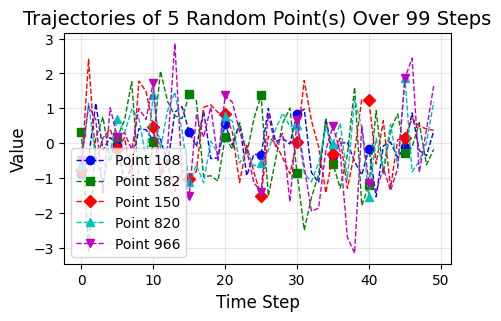

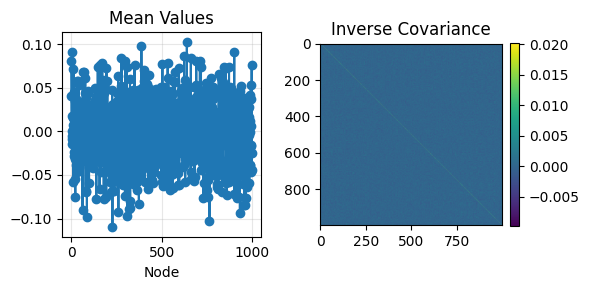

In [9]:
print(f"Signal matrix of shape {np.shape(S)}")
print("First 10 samples of the first 4 nodes:")
print(S[:10,:4])

stddev = np.std(S, axis=1)
print(f"Std across all nodes for the {np.shape(stddev)} samples")
print("Std for the first 10 samples:")
print(stddev[:10])
assert np.all(stddev > 1e-2)

plot_trajectories(S[:50,:], 5)
plot_mean_and_covariance(S)

# MLE (w/ and w/out Laplacian constraints)

In [10]:
Sigma = np.array(np.cov(S, rowvar=True, bias=False, ddof=1))
print(np.shape(Sigma))
print(f"Running GLASSO")
precision, covariance, convergence_results = glasso_fit(Sigma)
# results_glasso = block_descent(Sigma, 'glasso', A_mask=structure.toarray())
print(f"Running CGL")
precision, covariance, convergence_results = cgl_fit(Sigma, A_mask=structure.toarray())
# results_cgl = block_descent(Sigma, "cgl", A_mask=structure.toarray())

(99, 99)
Running GLASSO
Running CGL


In [11]:
class NumpyEncoder(json.JSONEncoder):
    def default(self, obj):
        if isinstance(obj, np.ndarray):
            return obj.tolist()
        elif isinstance(obj, (np.integer, np.int32, np.int64)):
            return int(obj)
        elif isinstance(obj, (np.floating, np.float32, np.float64)):
            return float(obj)
        elif isinstance(obj, bool):
            return bool(obj)
        return super(NumpyEncoder, self).default(obj)

x = []
A = structure.toarray()
L_true = L.toarray()

all_results = {}
all_results['parameters'] = {
    'num_equations': num_equations,
    'num_variables': num_variables,
    'max_degree': max_degree,
    'seed': seed,
    'epsilon': epsilon,
    'num_nodes': num_nodes,
    'L_true': L_true.tolist()
}
for i in range(3, 20):
    n_samples = 2**i
    x.append(n_samples)
    print("Generating", n_samples, "samples")
    all_results[str(n_samples)] = {}
    
    signals = generate_graph_signals(L_true, num_signals=n_samples)
    sample_cov = np.cov(signals, rowvar=True, bias=False, ddof=1)
    assert np.shape(sample_cov) == (99, 99)

    # Inverse Covariance
    print("  - Sample precision")
    precision = np.linalg.pinv(sample_cov)
    error_metrics = laplacian_error_metrics(L_true, precision)
    
    all_results[str(n_samples)]['pinv'] = {
        'results': precision.tolist(),
        'errors': error_metrics
    }
    
    # GLASSO
    print("  - GLASSO")
    results_glasso = glasso_fit(sample_cov)
    error_metrics = laplacian_error_metrics(L_true, results_glasso["O"])

    all_results[str(n_samples)]['glasso'] = {
        'results': results_glasso,
        'errors': error_metrics
    }
    
    # CGL
    print("  - CGL")
    results_cgl = cgl_fit(sample_cov, A_mask=A)
    error_metrics = laplacian_error_metrics(L_true, results_cgl["O"])

    all_results[str(n_samples)]['cgl'] = {
        'results': results_cgl,
        'errors': error_metrics
    }

now = datetime.now()
timestamp = now.strftime('%Y%m%d_%H%M%S')

with open(f"all_results_{timestamp}.json", "w") as f:
    json.dump(all_results, f, cls=NumpyEncoder, indent=2)

Generating 8 samples
  - Sample precision
  - GLASSO
  - CGL
Generating 16 samples
  - Sample precision
  - GLASSO
  - CGL
Generating 32 samples
  - Sample precision
  - GLASSO
  - CGL
Generating 64 samples
  - Sample precision
  - GLASSO
  - CGL
Generating 128 samples
  - Sample precision
  - GLASSO
  - CGL
Generating 256 samples
  - Sample precision
  - GLASSO
  - CGL
Generating 512 samples
  - Sample precision
  - GLASSO
  - CGL
Generating 1024 samples
  - Sample precision
  - GLASSO
  - CGL
Generating 2048 samples
  - Sample precision
  - GLASSO
  - CGL
Generating 4096 samples
  - Sample precision
  - GLASSO
  - CGL
Generating 8192 samples
  - Sample precision
  - GLASSO
  - CGL
Generating 16384 samples
  - Sample precision
  - GLASSO
  - CGL
Generating 32768 samples
  - Sample precision
  - GLASSO
  - CGL
Generating 65536 samples
  - Sample precision
  - GLASSO
  - CGL
Generating 131072 samples
  - Sample precision
  - GLASSO
  - CGL
Generating 262144 samples
  - Sample precision


In [12]:
def plot_from_all_results(all_results, title_prefix=None):
    x_values = sorted([int(k) for k in all_results.keys() if k.isdigit()])

    errors_pinv = {
        'frobenius_error': [all_results[str(x)]['pinv']['errors']['frobenius_error'] for x in x_values],
        'spectral_error': [all_results[str(x)]['pinv']['errors']['spectral_error'] for x in x_values],
        'subspace_error': [all_results[str(x)]['pinv']['errors']['subspace_error'] for x in x_values]
    }

    errors_glasso = {
        'frobenius_error': [all_results[str(x)]['glasso']['errors']['frobenius_error'] for x in x_values],
        'spectral_error': [all_results[str(x)]['glasso']['errors']['spectral_error'] for x in x_values],
        'subspace_error': [all_results[str(x)]['glasso']['errors']['subspace_error'] for x in x_values]
    }

    errors_cgl = {
        'frobenius_error': [all_results[str(x)]['cgl']['errors']['frobenius_error'] for x in x_values],
        'spectral_error': [all_results[str(x)]['cgl']['errors']['spectral_error'] for x in x_values],
        'subspace_error': [all_results[str(x)]['cgl']['errors']['subspace_error'] for x in x_values]
    }

    def plot_errors(errors, title):
        fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(10, 8), sharex=True)
        
        ax1.plot(x_values, errors["frobenius_error"], marker='o', linestyle='-', color='b', label='Frobenius Error')
        ax1.set_yscale('log')
        ax1.set_ylabel('Frobenius Error (log scale)')
        ax1.grid(True, which='both', linestyle='--', linewidth=0.5)
        ax1.legend()
        
        ax2.plot(x_values, errors["spectral_error"], marker='s', linestyle='--', color='g', label='Spectral Error')
        ax2.set_yscale('log')
        ax2.set_ylabel('Spectral Error (log scale)')
        ax2.grid(True, which='both', linestyle='--', linewidth=0.5)
        ax2.legend()
        
        ax3.plot(x_values, errors["subspace_error"], marker='^', linestyle='-.', color='r', label='Subspace Error')
        ax3.set_yscale('log')
        ax3.set_xscale('log')
        ax3.set_xlabel('Number of samples (log scale)')
        ax3.set_ylabel('Subspace Error (log scale)')
        ax3.grid(True, which='both', linestyle='--', linewidth=0.5)
        ax3.legend()
        
        plt.tight_layout()
        if title:
            plt.savefig(title, dpi=300, bbox_inches="tight")
        plt.show()

    plot_errors(errors_pinv, title=f"{title_prefix}_pinv.png" if title_prefix else None)
    plot_errors(errors_glasso, title=f"{title_prefix}_glasso.png" if title_prefix else None)
    plot_errors(errors_cgl, title=f"{title_prefix}_cgl.png" if title_prefix else None)

    return None

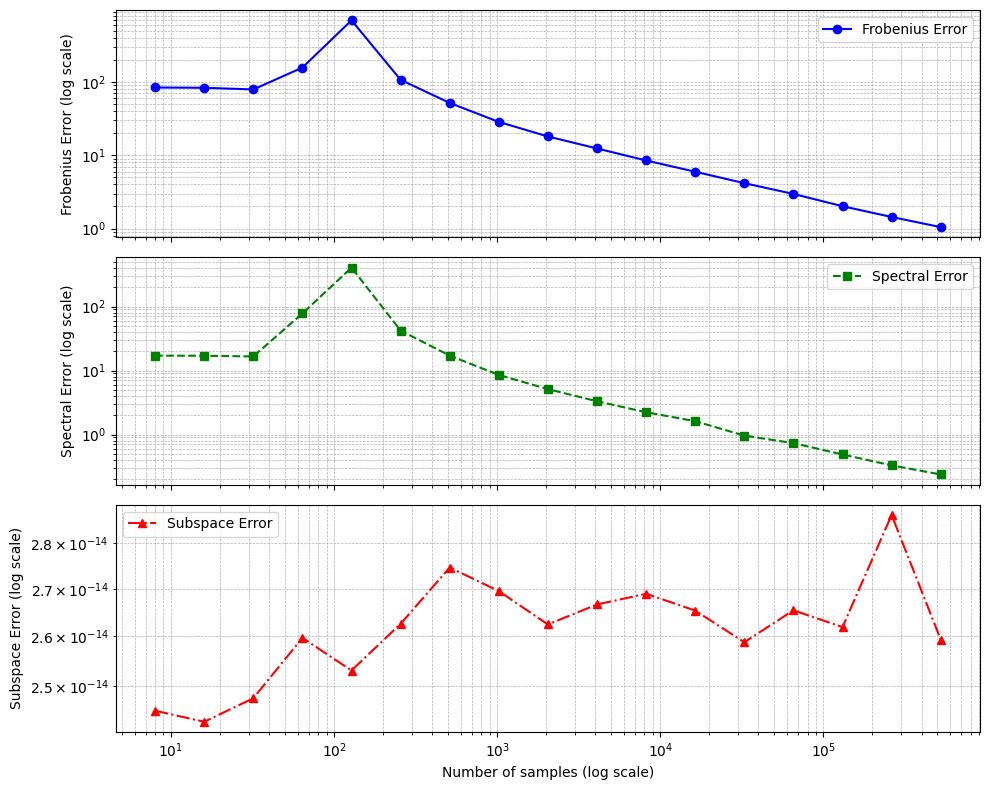

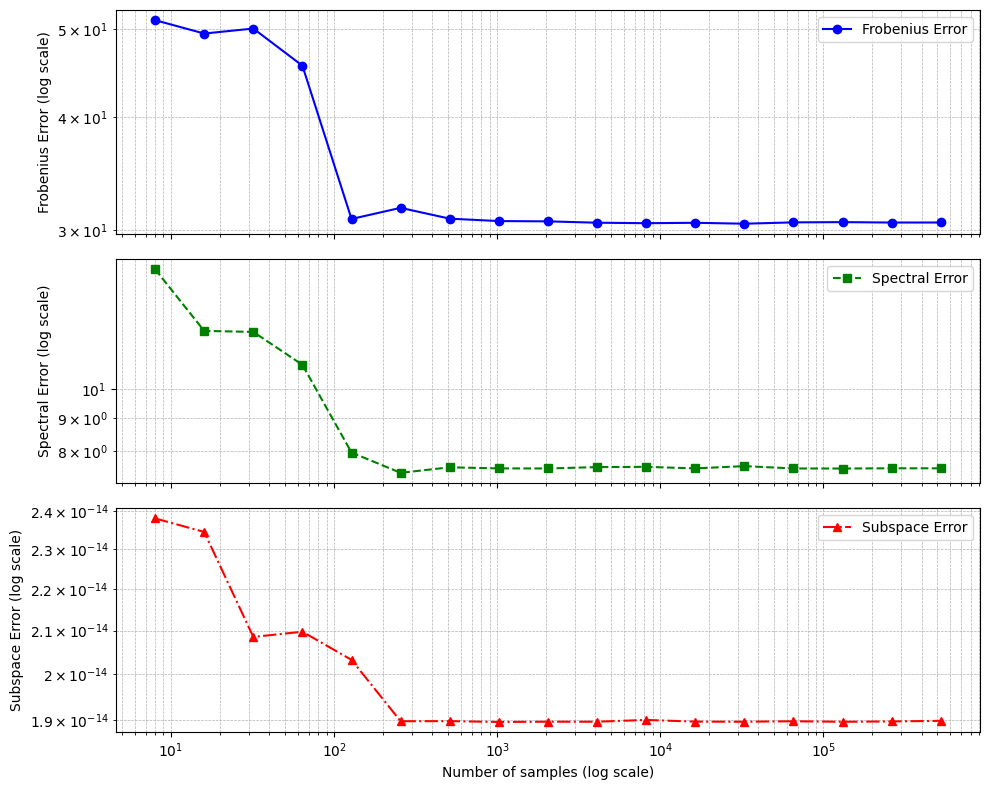

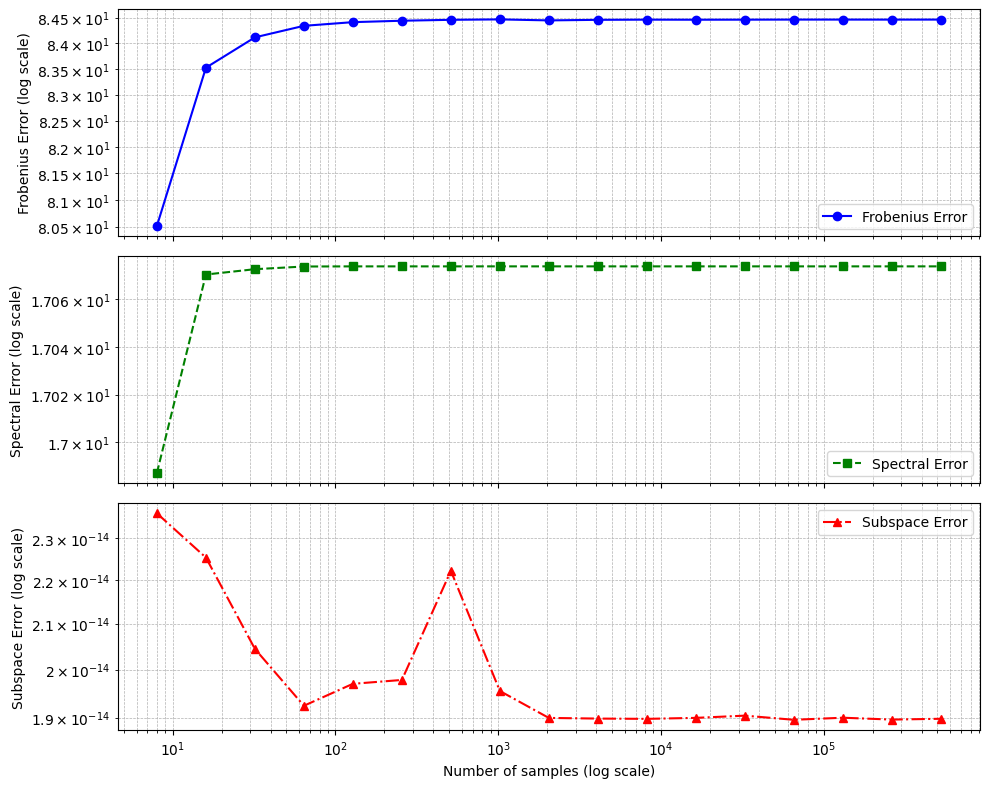

In [13]:
with open(f"all_results_{timestamp}.json", "r") as f:
    all_results_to_plot = json.load(f)

plot_from_all_results(all_results_to_plot, title_prefix=None)

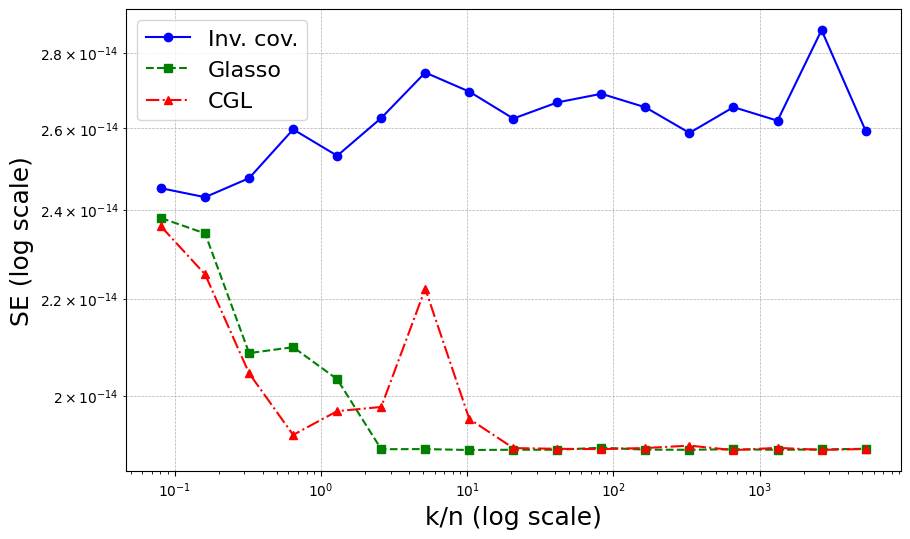

In [54]:
import matplotlib.ticker as ticker

def plot_selected_results(all_results, title_prefix=None):
    x_values = sorted([int(k) for k in all_results.keys() if k.isdigit()])

    errors_pinv = {
        'frobenius_error': [all_results[str(x)]['pinv']['errors']['frobenius_error'] for x in x_values],
        'spectral_error': [all_results[str(x)]['pinv']['errors']['spectral_error'] for x in x_values],
        'subspace_error': [all_results[str(x)]['pinv']['errors']['subspace_error'] for x in x_values]
    }

    errors_glasso = {
        'frobenius_error': [all_results[str(x)]['glasso']['errors']['frobenius_error'] for x in x_values],
        'spectral_error': [all_results[str(x)]['glasso']['errors']['spectral_error'] for x in x_values],
        'subspace_error': [all_results[str(x)]['glasso']['errors']['subspace_error'] for x in x_values]
    }

    errors_cgl = {
        'frobenius_error': [all_results[str(x)]['cgl']['errors']['frobenius_error'] for x in x_values],
        'spectral_error': [all_results[str(x)]['cgl']['errors']['spectral_error'] for x in x_values],
        'subspace_error': [all_results[str(x)]['cgl']['errors']['subspace_error'] for x in x_values]
    }

    x_values = [x/99 for x in x_values]

    # x_ = np.array(x_values)
    # errors_ = np.array(errors_pinv['frobenius_error'])
    # plt.figure(figsize=(10, 6))
    # plt.plot(x_, errors_, marker='o', linestyle='-', label='Inv. cov.')
    # plt.xscale('log')
    # plt.yscale('log')
    # plt.xlabel('k/n (log scale)')
    # plt.ylabel('RE (log scale)')
    # plt.grid(True, which='major', linestyle='--', linewidth=0.5)

    # x_model = np.logspace(np.log10(x_.min()), np.log10(x_.max()), 200)
    # c = 2 - x_.min()
    # a = errors_[0] * np.log(x_[0] + c) + 100
    # p = 0.2
    # k = 4
    # y_model = a / (x_model ** p * np.log(x_model + c) ** k)
    
    # plt.plot(x_model, y_model, 'r--', label='Objective')
    # plt.legend(loc='upper left',bbox_to_anchor=(1.005, 1))
    # plt.tick_params(axis='both', which='major')
    # plt.ylim(1e-1, 1e3)
    # if title_prefix:
    #     plt.savefig(f'{title_prefix}_pinv_re.pdf', format='pdf', bbox_inches='tight')
    # plt.show()

    plt.figure(figsize=(10, 6))
    plt.plot(x_values, errors_pinv['subspace_error'], marker='o', linestyle='-', color='b', label='Inv. cov.')
    plt.plot(x_values, errors_glasso['subspace_error'], marker='s', linestyle='--', color='g', label='Glasso')
    plt.plot(x_values, errors_cgl['subspace_error'], marker='^', linestyle='-.', color='r', label='CGL')
    plt.yscale('log')
    plt.xscale('log')
    plt.xlabel('k/n (log scale)', fontsize=18)
    plt.ylabel('SE (log scale)', fontsize=18)
    plt.grid(axis='x', which='major', linestyle='--', linewidth=0.5)
    plt.grid(axis='y', which='both', linestyle='--', linewidth=0.5)
    plt.tick_params(axis='both', which='major')
    plt.legend(fontsize=16)
    if title_prefix:
        plt.savefig(f'{title_prefix}_subspace_error.pdf', format='pdf', bbox_inches='tight')
    plt.show()

    return None

with open(f"all_results_{timestamp}.json", "r") as f:
    all_results_to_plot = json.load(f)

plot_selected_results(all_results_to_plot, title_prefix=f"plot_{timestamp}")

In [15]:
elapsed_pinv_list = []
elapsed_glasso_list = []
elapsed_cgl_list = []
x = []

probs = np.array([[0.3, 0.01, 0.02],
                  [0.01, 0.25, 0.03],
                  [0.02, 0.03, 0.2]])

for i in range(4, 10):
    n_ = 3**i
    
    print(f"Running for {n_} nodes")
    
    sizes = [n_//3, n_//3, n_//3]    
    A_ = create_sbm(sizes, probs)
    
    num_nodes = sum(sizes)
    x.append(num_nodes)
    
    L, W, point_cloud, epsilon = GraphSampler().create_weighted_graph_from_structure(M, A_)
    L_dense = L.toarray()
    np.fill_diagonal(L_dense, 0)

    X = generate_graph_signals(L_dense, num_signals=1000)

    sample_cov = np.cov(X, rowvar=True, bias=False, ddof=1)
    assert np.shape(sample_cov) == (num_nodes, num_nodes), f"Expected {(num_nodes, num_nodes)}, got {np.shape(sample_cov)}"

    # Inverse Covariance
    print("  - Sample precision")
    start_time = time.perf_counter()
    _ = np.linalg.pinv(sample_cov)
    elapsed_pinv = time.perf_counter() - start_time
    elapsed_pinv_list.append(elapsed_pinv)
    
    # GLASSO
    print("  - GLASSO")
    start_time = time.perf_counter()
    _ = glasso_fit(sample_cov)
    elapsed_glasso = time.perf_counter() - start_time
    elapsed_glasso_list.append(elapsed_glasso)

    # CGL
    print("  - CGL")
    start_time = time.perf_counter()
    _ = cgl_fit(sample_cov, A_mask=A_.toarray())
    elapsed_cgl = time.perf_counter() - start_time
    elapsed_cgl_list.append(elapsed_cgl)

results = {
    'num_equations': num_equations,
    'num_variables': num_variables,
    'max_degree': max_degree,
    'seed': seed,
    'sbm_probs': probs,
    'nodes': x,
    'pinv': elapsed_pinv_list,
    'glasso': elapsed_glasso_list,
    'cgl': elapsed_cgl_list
}

now = datetime.now()
timestamp = now.strftime('%Y%m%d_%H%M%S')

with open(f'performance_results_{timestamp}.json', 'w') as f:
    json.dump(results, f)

Running for 81 nodes
  - Sample precision
  - GLASSO
  - CGL


/home/en4624/ghorg/graphdatahub/NetworkInference/.venv/lib/python3.12/site-packages/numpy/core/numeric.py:925: RuntimeWarning: overflow encountered in multiply
  return multiply(a.ravel()[:, newaxis], b.ravel()[newaxis, :], out)
/home/en4624/ghorg/graphdatahub/NetworkInference/src/gso/gso_learning/cgl.py:122: RuntimeWarning: invalid value encountered in matmul
  b = k_u / k_uu + (1 / n) * Ou_i @ np.ones(n - 1)
/home/en4624/ghorg/graphdatahub/NetworkInference/src/gso/gso_learning/cgl.py:132: RuntimeWarning: invalid value encountered in matmul
  o_uu = (1 / k_uu) + o_u @ Ou_i @ o_u
/home/en4624/ghorg/graphdatahub/NetworkInference/src/gso/gso_learning/cgl.py:134: RuntimeWarning: invalid value encountered in matmul
  denom = o_uu - o_u @ Ou_i @ o_u
/home/en4624/ghorg/graphdatahub/NetworkInference/src/gso/gso_learning/cgl.py:138: RuntimeWarning: invalid value encountered in matmul
  cu = (Ou_i @ o_u) / denom


RuntimeError: Invalid precision matrix (post-BU): contains NaN values

In [ ]:
with open(f'performance_results_{timestamp}.json', 'r') as f:
    loaded_results = json.load(f)

x = loaded_results['nodes']
elapsed_pinv_list = loaded_results['pinv']
elapsed_glasso_list = loaded_results['glasso']
elapsed_cgl_list = loaded_results['cgl']

plt.figure(figsize=(10, 6))
plt.loglog(x, elapsed_pinv_list, label='Sample Precision (pinv)', marker='o')
plt.loglog(x, elapsed_glasso_list, label='GLASSO', marker='o')
plt.loglog(x, elapsed_cgl_list, label='CGL', marker='o')
plt.xlabel('Number of nodes (log scale)')
plt.ylabel('Elapsed time (seconds, log scale)')
plt.title('Performance of methods as number of nodes increases')
plt.legend()
plt.grid(True, which='both', ls='--')
plt.tight_layout()
plt.show()